In [2]:
#Add folders containing data you want to use

##Saline 
RecordingsToUse = [r'\\goeppert\nlab-nas\Rolf\Freely Moving Ephys\2024\052124\J691RT',
                   r'D:\080524\J705RT',
                   r'D:\080924\J720LT',
                   r'D:\081924\J716LT']



In [1]:
#Mice used for Sparse Noise Comparison

RecordingsToUse = [r'D:\080524\J705RT',
                   r'D:\080924\J720LT',
                   r'D:\081924\J716LT']


In [4]:
#Importing Important Stuff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics as stat 
import math 
from pylab import *
import os
import fmEphys as fme

import sys
sys.path.append(r"C:\Users\Niell Lab\Documents\GitHub\freely-moving-saccades")
import saccadeAnalysis as sacc

In [5]:
def calc_std_modidx(psth,thresh):
 
    psth = psth.astype(float)
    psth = psth - np.nanmean(psth[200:800])

    std_thresh = np.nanstd(psth[200:800]*thresh)
    
    if np.nanmax((np.abs(psth[1000:1250])-std_thresh)) > 0:
        mod = 1
    else:
        mod = 0 
    return mod
    

def calc_fr_modidx(psth,thresh):

    psth = psth.astype(float)
    psth = psth - np.nanmean(psth[200:800])

    if np.nanmax(np.abs(psth[1000:1250])) > thresh:
        mod = 1
    else:
        mod = 0
    return mod

def calc_saccade_MM(psth):
    data = psth - np.nanmean(psth[200:800])
    data = data[1000:1250]
    latency = np.argmax(np.abs(data))
    MM = data[latency]
    return MM, latency

In [6]:
#Collecting Data Files for Analysis (Currently Just Collecting FM and Grating .h5 files)

FM_Files = [[] for _ in range(len(RecordingsToUse))]
Grating_Files = [[] for _ in range(len(RecordingsToUse))]

RC_Files = [[] for _ in range(len(RecordingsToUse))]
Single_Unit_Files = []
Grating_Mice =[[] for _ in range(len(RecordingsToUse))]
for ii in list(range(0,len(RecordingsToUse))):
    
    #Finding FM ephys files before DOI 
    RecordingPath = RecordingsToUse[ii]
    PreFM_Path = RecordingPath + '/fm1'
    Items = os.listdir(PreFM_Path)
    for names in Items:
        if names.endswith("ephys_props.h5"):
            FM_Files[ii].append(PreFM_Path + '/' + names)
            
        
    #Finding FM ephys files after DOI         
    PostFM_Path = RecordingPath + '/fm2'           
    Items = os.listdir(PostFM_Path)
    for names in Items:
        if names.endswith("ephys_props.h5"):
            FM_Files[ii].append(PostFM_Path + '/' + names)

    #Finding Single Unit .npy file for each recording

    for Items in os.listdir(RecordingPath):
        if Items.endswith("SingleUnits_NoThresh.npy"):
           Single_Unit_Files.append(RecordingPath +'/' + Items)
           

    #Finding drifting grating ephys .h5 files


In [7]:
#Creating Master dataframe with recordings of interest

PreFM_Data = pd.DataFrame()
PostFM_Data = pd.DataFrame()

PreGrating_Data = pd.DataFrame()
PostGrating_Data = pd.DataFrame()

PreRC_Data = pd.DataFrame()
PostRC_Data = pd.DataFrame()

for ii in list(range(0,len(RecordingsToUse))):

    date = os.path.basename(os.path.dirname(RecordingsToUse[ii]))
    mouse = os.path.basename(RecordingsToUse[ii])
    DateAndMouse = date + '_' + mouse

    Single_Units = np.load(Single_Unit_Files[ii])
    print(len(Single_Units))


    PreFM_Data_temp = pd.read_hdf(FM_Files[ii][0])
    PreFM_Data_temp['Mouse'] = DateAndMouse
    PreFM_Data_temp = PreFM_Data_temp.loc[Single_Units]
    

    PostFM_Data_temp = pd.read_hdf(FM_Files[ii][1])
    PostFM_Data_temp['Mouse'] = DateAndMouse
    PostFM_Data_temp =PostFM_Data_temp.loc[Single_Units]

    PreFM_Data = pd.concat([PreFM_Data, PreFM_Data_temp])
    PostFM_Data = pd.concat([PostFM_Data, PostFM_Data_temp])

 
PreFM_Data['spike_sort_idx'] =PreFM_Data.index
PreFM_Data = PreFM_Data.reset_index()

PostFM_Data['spike_sort_idx'] =PostFM_Data.index
PostFM_Data = PostFM_Data.reset_index()

print( )
print(len(PreFM_Data))
print('Done!')

19
50
145
50

264
Done!


In [8]:
data = []
data_comp = []

Cells = np.stack(PreFM_Data.loc[:,'index'])

#Kernel for filtering
kernel_size = 100
kernel = np.ones(kernel_size) / kernel_size

for ii in list(PreFM_Data.index):

    Mouse = PreFM_Data.loc[ii,'Mouse']

    #################################################################################################################
    #Lightly Filter Pre and Post Drug Gaze and Comp Responses
    Pre_Left_Gaze_filt = np.convolve(PreFM_Data.loc[ii,'FmLt_gazeshift_leftPSTH'], kernel, mode='same')
    Pre_Right_Gaze_filt = np.convolve(PreFM_Data.loc[ii,'FmLt_gazeshift_rightPSTH'], kernel, mode='same')
    Pre_Left_Comp_filt = np.convolve(PreFM_Data.loc[ii,'FmLt_compensatory_leftPSTH'], kernel, mode='same')
    Pre_Right_Comp_filt = np.convolve(PreFM_Data.loc[ii,'FmLt_compensatory_rightPSTH'], kernel, mode='same')

    Post_Left_Gaze_filt= np.convolve(PostFM_Data.loc[ii,'FmLt_gazeshift_leftPSTH'], kernel, mode='same')
    Post_Right_Gaze_filt = np.convolve(PostFM_Data.loc[ii,'FmLt_gazeshift_rightPSTH'], kernel, mode='same')
    Post_Left_Comp_filt = np.convolve(PostFM_Data.loc[ii,'FmLt_compensatory_leftPSTH'], kernel, mode='same')
    Post_Right_Comp_filt = np.convolve(PostFM_Data.loc[ii,'FmLt_compensatory_rightPSTH'], kernel, mode='same')

    #Pre_Left_Gaze_filt = PreFM_Data.loc[ii,'FmLt_gazeshift_leftPSTH']
    #Pre_Right_Gaze_filt = PreFM_Data.loc[ii,'FmLt_gazeshift_rightPSTH']
    #Pre_Left_Comp_filt = PreFM_Data.loc[ii,'FmLt_compensatory_leftPSTH']
    #Pre_Right_Comp_filt = PreFM_Data.loc[ii,'FmLt_compensatory_rightPSTH']

    #Post_Left_Gaze_filt= PostFM_Data.loc[ii,'FmLt_gazeshift_leftPSTH']
    #Post_Right_Gaze_filt = PostFM_Data.loc[ii,'FmLt_gazeshift_rightPSTH']
    #Post_Left_Comp_filt = PostFM_Data.loc[ii,'FmLt_compensatory_leftPSTH']
    #Post_Right_Comp_filt = PostFM_Data.loc[ii,'FmLt_compensatory_rightPSTH']








    
    #################################################################################################################
    #Subtracting off baseline
    Pre_Left_Gaze = Pre_Left_Gaze_filt - np.nanmean(Pre_Left_Gaze_filt[200:800])
    Pre_Right_Gaze = Pre_Right_Gaze_filt - np.nanmean(Pre_Right_Gaze_filt[200:800])
    Pre_Left_Comp = Pre_Left_Comp_filt - np.nanmean(Pre_Left_Comp_filt[200:800])
    Pre_Right_Comp = Pre_Right_Comp_filt - np.nanmean(Pre_Right_Comp_filt[200:800])

    Post_Left_Gaze = Post_Left_Gaze_filt - np.nanmean(Post_Left_Gaze_filt[200:800])
    Post_Right_Gaze = Post_Right_Gaze_filt - np.nanmean(Post_Right_Gaze_filt[200:800])
    Post_Left_Comp = Post_Left_Comp_filt - np.nanmean(Post_Left_Comp_filt[200:800])
    Post_Right_Comp = Post_Right_Comp_filt - np.nanmean(Post_Right_Comp_filt[200:800])

    #################################################################################################################
    #Calculating Max Modulations - This use baseline subtracted values
    Pre_Left_Gaze_MM = calc_saccade_MM(Pre_Left_Gaze_filt)[0]
    Pre_Right_Gaze_MM = calc_saccade_MM(Pre_Right_Gaze_filt)[0]
    
    Post_Left_Gaze_MM = calc_saccade_MM(Post_Left_Gaze_filt)[0]  
    Post_Right_Gaze_MM = calc_saccade_MM(Post_Right_Gaze_filt)[0]  

    #################################################################################################################
    #Calculating Preferred Gaze and Comp Response Pre and Post Drug
    Pre_Gaze_DS = (np.abs(Pre_Left_Gaze_MM) - np.abs(Pre_Right_Gaze_MM))/(np.abs(Pre_Left_Gaze_MM) + np.abs(Pre_Right_Gaze_MM))
    Post_Gaze_DS = (np.abs(Post_Left_Gaze_MM) - np.abs(Post_Right_Gaze_MM))/(np.abs(Post_Left_Gaze_MM) + np.abs(Post_Right_Gaze_MM)) 

    Pre_Comp_DS = (np.max(np.abs(Pre_Left_Comp[1000:1250])) - np.max(np.abs(Pre_Right_Comp[1000:1250])))/(np.max(np.abs(Pre_Left_Comp[1000:1250])) + np.max(np.abs(Pre_Right_Comp[1000:1250])))
    Post_Comp_DS = (np.max(np.abs(Post_Left_Comp[1000:1250])) - np.max(np.abs(Post_Right_Comp[1000:1250])))/(np.max(np.abs(Post_Left_Comp[1000:1250])) + np.max(np.abs(Post_Right_Comp[1000:1250]))) 

    ################################################################################################################
    #Finding Preferred and Non Pref Pre Drug Gaze
    if Pre_Gaze_DS > 0:
        Pref_Gaze_Pre_Raw = PreFM_Data.loc[ii,'FmLt_gazeshift_leftPSTH']
        Pref_Gaze_Pre = Pre_Left_Gaze
        Pref_GazeTimes_Pre = PreFM_Data.loc[ii,'FmLt_gazeshift_leftT']
    else:
        Pref_Gaze_Pre_Raw = PreFM_Data.loc[ii,'FmLt_gazeshift_rightPSTH']
        Pref_Gaze_Pre = Pre_Right_Gaze  
        Pref_GazeTimes_Pre = PreFM_Data.loc[ii,'FmLt_gazeshift_rightT']
    #Finding Preferred and Non Pref Post Drug Gaze
    if Post_Gaze_DS > 0:
        Pref_Gaze_Post_Raw = PostFM_Data.loc[ii,'FmLt_gazeshift_leftPSTH']
        Pref_Gaze_Post = Post_Left_Gaze
        Pref_GazeTimes_Post = PostFM_Data.loc[ii,'FmLt_gazeshift_leftT']
    else:
        Pref_Gaze_Post_Raw = PostFM_Data.loc[ii,'FmLt_gazeshift_rightPSTH']
        Pref_Gaze_Post = Post_Right_Gaze  
        Pref_GazeTimes_Post = PostFM_Data.loc[ii,'FmLt_gazeshift_rightT']

    ################################################################################################################
    #Finding Max Modulation and Latency of Preferred Responses Pre and Post Drug
    temp = calc_saccade_MM(Pref_Gaze_Pre)
    Pref_Gaze_Pre_Latency = temp[1]
    Pref_Gaze_Pre_MM = temp[0]

    temp = calc_saccade_MM(Pref_Gaze_Post)
    Pref_Gaze_Post_Latency = temp[1]
    Pref_Gaze_Post_MM = temp[0]

    #################################################################################################################
    #Normalizing Pref Gaze Responses and applying thresholds to 
    Pref_Gaze_Pre_Norm_4Clust = Pref_Gaze_Pre/np.abs(Pref_Gaze_Pre_MM)
    Pref_Gaze_Post_Norm_4Clust = Pref_Gaze_Post/np.abs(Pref_Gaze_Post_MM)

    Pre_STD_Thresh = calc_std_modidx(Pref_Gaze_Pre,3.5)
    Pre_FR_Thresh = calc_fr_modidx(Pref_Gaze_Pre_Raw,1)

    Pre_Responsive = 1
    if (Pre_STD_Thresh == 0) or (Pre_FR_Thresh == 0):
        Pref_Gaze_Pre_Norm_4Clust[:] = 0
        Pre_Responsive = 0

    Post_STD_Thresh = calc_std_modidx(Pref_Gaze_Post,3.5)
    Post_FR_Thresh = calc_fr_modidx(Pref_Gaze_Post_Raw,1)

    Post_Responsive = 1
    if (Post_STD_Thresh == 0) or (Post_FR_Thresh == 0):
        Pref_Gaze_Post_Norm_4Clust[:] = 0
        Post_Responsive = 0



    #################################################################################################################
    #Finding Preferred and Non Pref Pre Drug Comp
    if Pre_Comp_DS > 0:
        Pref_Comp_Pre_Raw = PreFM_Data.loc[ii,'FmLt_compensatory_leftPSTH']
        Pref_Comp_Pre = Pre_Left_Comp

    else:
        Pref_Comp_Pre_Raw = PreFM_Data.loc[ii,'FmLt_compensatory_rightPSTH']
        Pref_Comp_Pre = Pre_Right_Comp  

    #Finding Preferred and Non Pref Post Drug Comp
    if Post_Comp_DS > 0:
        Pref_Comp_Post_Raw = PostFM_Data.loc[ii,'FmLt_compensatory_leftPSTH']
        Pref_Comp_Post = Post_Left_Comp

    else:
        Pref_Comp_Post_Raw = PostFM_Data.loc[ii,'FmLt_compensatory_rightPSTH']
        Pref_Comp_Post = Post_Right_Comp 

    #################################################################################################################
    data.append({'Mouse': Mouse, 'Cell': Cells[ii], 'Pre_Responsive': Pre_Responsive, 'Post_Responsive': Post_Responsive, 
                'Pre_Gaze_DS': Pre_Gaze_DS, 'Pref_Gaze_Pre_Raw': Pref_Gaze_Pre_Raw, 'Pref_Gaze_Pre': Pref_Gaze_Pre, 'Pref_Gaze_Pre_Norm_4Clust': Pref_Gaze_Pre_Norm_4Clust,
                'Pref_Gaze_Pre_Baseline': np.nanmean(Pref_Gaze_Pre_Raw[:800]),'Pref_Gaze_Pre_Latency': Pref_Gaze_Pre_Latency, 'Pref_Gaze_Pre_MM': Pref_Gaze_Pre_MM, 'Pref_GazeTimes_Pre': Pref_GazeTimes_Pre,
                'Post_Gaze_DS': Post_Gaze_DS, 'Pref_Gaze_Post_Raw': Pref_Gaze_Post_Raw, 'Pref_Gaze_Post': Pref_Gaze_Post, 'Pref_Gaze_Post_Norm_4Clust': Pref_Gaze_Post_Norm_4Clust,
                'Pref_Gaze_Post_Baseline': np.nanmean(Pref_Gaze_Post_Raw[:800]),'Pref_Gaze_Post_Latency': Pref_Gaze_Post_Latency, 'Pref_Gaze_Post_MM': Pref_Gaze_Post_MM, 'Pref_GazeTimes_Post': Pref_GazeTimes_Post,
                'Pre_SpikeT': PreFM_Data.loc[ii,'FmLt_spikeT'], 'Post_SpikeT': PostFM_Data.loc[ii,'FmLt_spikeT']})

    data_comp.append({'Mouse': Mouse, 'Cell': Cells[ii],
                 'Pre_Comp_DS': Pre_Comp_DS, 'Pref_Comp_Pre_Raw': Pref_Comp_Pre_Raw, 'Pref_Comp_Pre': Pref_Comp_Pre, 'Pref_Comp_Pre_Baseline': np.nanmean(Pref_Comp_Pre_Raw[:800]),
                 'Post_Comp_DS': Post_Comp_DS, 'Pref_Comp_Post_Raw': Pref_Comp_Post_Raw, 'Pref_Comp_Post': Pref_Comp_Post, 'Pref_Comp_Post_Baseline': np.nanmean(Pref_Comp_Post_Raw[:800])})
                 
df = pd.DataFrame(data)    
df_comp = pd.DataFrame(data_comp)    



In [10]:
df.to_hdf(os.path.join(os.path.join('D:\PrePostDOI\Saline Datasets','AllMice_GazeShift_Saline.h5')), 'w')
df_comp.to_hdf(os.path.join(os.path.join('D:\PrePostDOI\Saline Datasets','AllMice_Compensatory_Saline.h5')), 'w')

Can Stop Here - Below is Extra Stuff

In [ ]:
import fmEphys as fme
import pickle

Pref_Gaze_Pre_Norm = np.stack(df.loc[:,'Pref_Gaze_Pre_Norm_4Clust'])
Pref_Gaze_Post_Norm = np.stack(df.loc[:,'Pref_Gaze_Post_Norm_4Clust'])

Pref_Gaze_Post_Norm[np.isnan(Pref_Gaze_Post_Norm)] = 0

# Specify the path to the KMeans model pickle file
km_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/KMeans_PSTH_model_062022.pickle'
pca_model_path = r'//goeppert/nlab-nas/Shelby/SC_analysis/PCA_PSTH_model_062022.pickle'
with open(km_model_path, 'rb') as f:
    kmeans_model = pickle.load(f)
with open(pca_model_path, 'rb') as f:
    pca = pickle.load(f)

# Transform into PC space.
proj = pca.transform(Pref_Gaze_Pre_Norm[:, 950:1300])

    # Only keep required PCs
gproj = proj[:,:4]

    # Map onto k-means clusters.
PreSaline_Labels = kmeans_model.predict(gproj)

projpost = pca.transform(Pref_Gaze_Post_Norm[:, 950:1300])
gprojpost = projpost[:,:4]
PostSaline_Labels = kmeans_model.predict(gprojpost)


In [80]:
for ii in range(0, len(df)):


    fig, axs = plt.subplots(2,2, figsize = [20,10])
    axs = axs.ravel()

    axs[0].plot(df.loc[ii,'Pref_Gaze_Pre_Raw'],color='black')
    axs[0].plot(df.loc[ii,'Pref_Gaze_Post_Raw'],color='lime')
    axs[0].set_title([df.loc[ii,'Mouse'], df.loc[ii,'Cell']])
    axs[2].plot(df.loc[ii,'Pref_Gaze_Pre'],color='black')
    axs[2].axhline(3.5*np.nanstd(df.loc[ii,'Pref_Gaze_Pre'][200:800]))

    axs[3].plot(df.loc[ii,'Pref_Gaze_Post'],color='lime')
    axs[3].axhline(3.5*np.nanstd(df.loc[ii,'Pref_Gaze_Post'][200:800]))

    axs[1].plot(df.loc[ii,'Pref_Gaze_Pre_Norm_4Clust'],color='black')
    axs[1].plot(df.loc[ii,'Pref_Gaze_Post_Norm_4Clust'],color='lime')

    axs[1].set_title([PreSaline_Labels[ii],PostSaline_Labels[ii]])

    if PreSaline_Labels[ii] == 0: 
        plt.savefig("D:/PrePostDOI/Gaze Responses/Pre Post Saline/Unresponsive/" + "/Cell " +str(ii) + '.png',bbox_inches='tight')
    if PreSaline_Labels[ii] == 1:
        plt.savefig("D:/PrePostDOI/Gaze Responses/Pre Post Saline/Biphasic" + "/Cell " +str(ii) + '.png',bbox_inches='tight')
    if PreSaline_Labels[ii] == 2: 
        plt.savefig("D:/PrePostDOI/Gaze Responses/Pre Post Saline/Late" + "/Cell " +str(ii) + '.png',bbox_inches='tight')
    if PreSaline_Labels[ii] == 3: 
        plt.savefig("D:/PrePostDOI/Gaze Responses/Pre Post Saline/Early" + "/Cell " +str(ii) + '.png',bbox_inches='tight')
    if PreSaline_Labels[ii] == 4: 
        plt.savefig("D:/PrePostDOI/Gaze Responses/Pre Post Saline/Negative" + "/Cell " +str(ii) + '.png',bbox_inches='tight')
    plt.close(fig)

0.2102803738317757
0.26635514018691586
0.20093457943925233
0.18691588785046728
0.13551401869158877


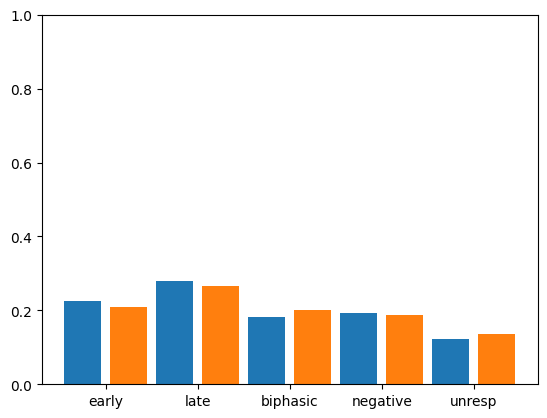

In [72]:
biphasic = np.sum(PreSaline_Labels== 1)/len(PreSaline_Labels)
negative = np.sum(PreSaline_Labels== 4)/len(PreSaline_Labels)
late = np.sum(PreSaline_Labels== 2)/len(PreSaline_Labels)
early = np.sum(PreSaline_Labels== 3)/len(PreSaline_Labels)
unresp = np.sum(PreSaline_Labels== 0)/len(PreSaline_Labels)



plt.bar([1,3,5,7,9],[early1, late1, biphasic1, negative1,unresp1])
plt.bar([2,4,6,8,10],[early, late, biphasic, negative,unresp])
#plt.bar([2,4,6,8,10],[82/716,135/716,170/716,66/716,263/716],color = 'black')
plt.xticks(ticks=[1.5,3.5,5.5,7.5,9.5],labels=['early', 'late', 'biphasic','negative','unresp'])
plt.ylim([0, 1])
print(early)
print(late)
print(biphasic)
print(negative)
print(unresp)

Text(0.5, 1.0, '[4, 0]')

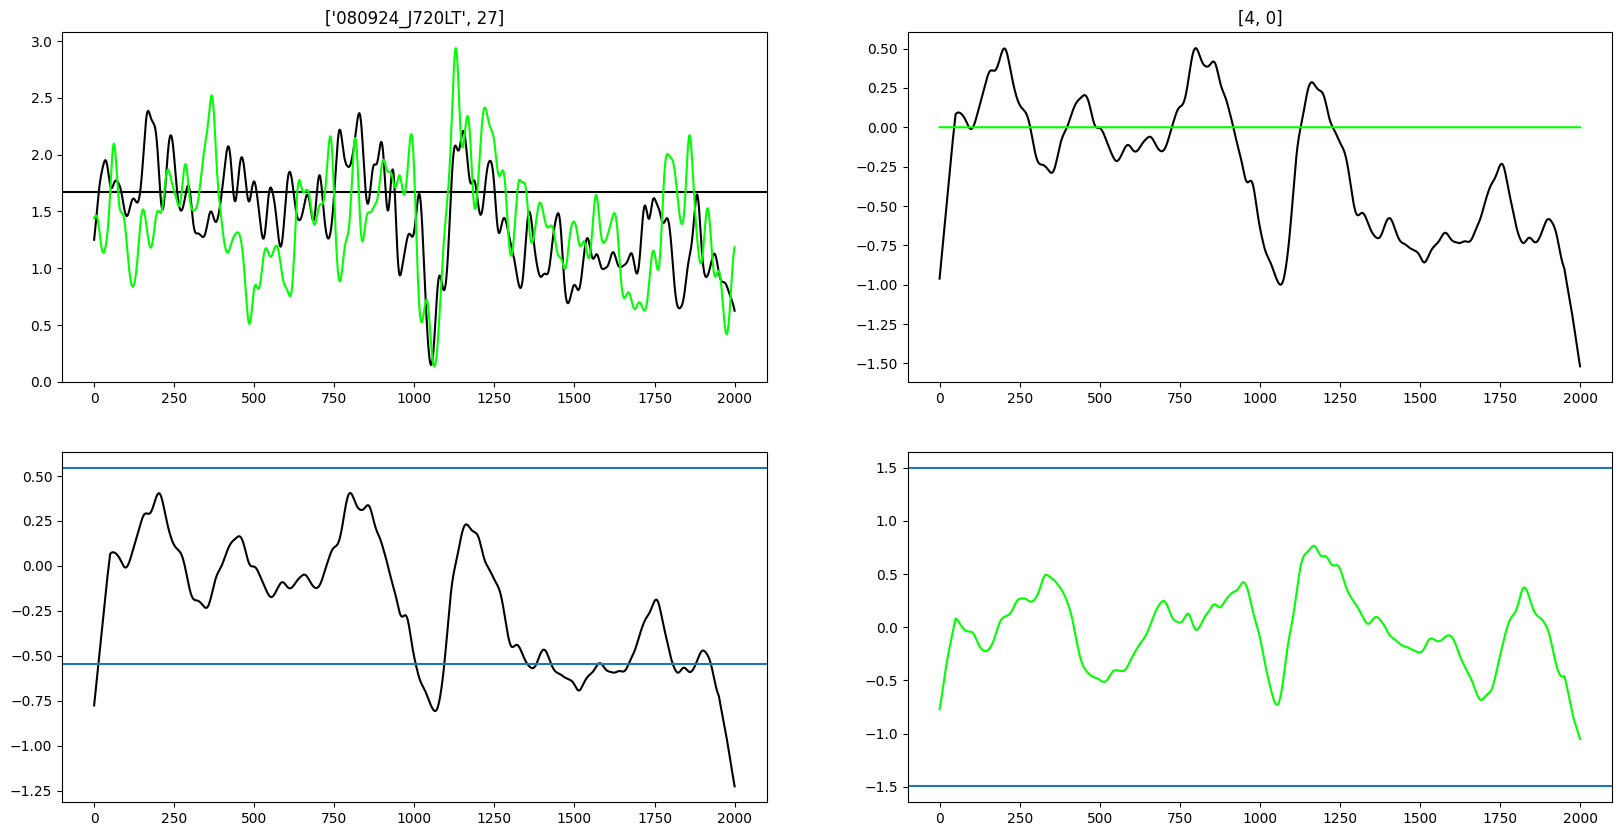

In [60]:
ii = 83
fig, axs = plt.subplots(2,2, figsize = [20,10])
axs = axs.ravel()

axs[0].plot(df.loc[ii,'Pref_Gaze_Pre_Raw'],color='black')
axs[0].axhline(np.nanmean(df.loc[ii,'Pref_Gaze_Pre_Raw'][0:800]),color='black')

axs[0].plot(df.loc[ii,'Pref_Gaze_Post_Raw'],color='lime')
axs[0].set_title([df.loc[ii,'Mouse'], df.loc[ii,'Cell']])
axs[2].plot(df.loc[ii,'Pref_Gaze_Pre'],color='black')
axs[2].axhline(3.5*np.nanstd(df.loc[ii,'Pref_Gaze_Pre'][200:800]))
axs[2].axhline(-3.5*np.nanstd(df.loc[ii,'Pref_Gaze_Pre'][200:800]))

axs[3].plot(df.loc[ii,'Pref_Gaze_Post'],color='lime')
axs[3].axhline(3.5*np.nanstd(df.loc[ii,'Pref_Gaze_Post_Raw'][200:800]))
axs[3].axhline(-3.5*np.nanstd(df.loc[ii,'Pref_Gaze_Post_Raw'][200:800]))

axs[1].plot(df.loc[ii,'Pref_Gaze_Pre_Norm_4Clust'],color='black')
axs[1].plot(df.loc[ii,'Pref_Gaze_Post_Norm_4Clust'],color='lime')

axs[1].set_title([PreSaline_Labels[ii],PostSaline_Labels[ii]])

1

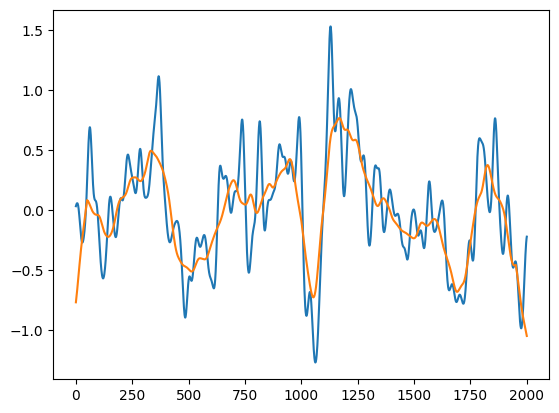

In [59]:

#plt.plot((df.loc[ii,'Pref_Gaze_Pre_Raw']-np.nanmean(df.loc[ii,'Pref_Gaze_Pre_Raw'][0:800])))
#plt.plot(df.loc[ii,'Pref_Gaze_Pre'])

plt.plot((df.loc[ii,'Pref_Gaze_Post_Raw']-np.nanmean(df.loc[ii,'Pref_Gaze_Post_Raw'][0:800])))
plt.plot(df.loc[ii,'Pref_Gaze_Post'])

calc_fr_modidx(df.loc[ii,'Pref_Gaze_Post_Raw'],1)
calc_std_modidx(df.loc[ii,'Pref_Gaze_Post_Raw'],3.5)